In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
import pandas as pd 
from scipy.ndimage import uniform_filter1d
import plotly.graph_objects as go
from joblib import Parallel, delayed
import os

In [7]:
with open("constellaration_row0.json", "r") as f:
    row = json.load(f)

In [8]:
# cylindrical coordinates
r_cos = np.array(row["boundary.r_cos"])   # Fourier coefficients for the cosine terms, shape: (n_periodicity+1, 2*n_periodicity+1) or flat
z_sin = np.array(row["boundary.z_sin"])   # Fourier coefficients for the sine terms, same shape
Nfp   = row["boundary.n_field_periods"]   # number of field periods
nmax  = row["boundary.n_periodicity"]     # max poloidal/toroidal mode number, max number of terms in the Fourier, controls model simplicity

In [9]:
r_coil = 0.65
R_inner = 0.3 
R_outer = R_inner + 2*r_coil
R_centre = R_inner + r_coil

m_max: 5   nmax_actual: 4
R_00: 0.9994871156625027
R range: 0.6506282425032026 1.2890100022946422
Z range: -0.3147245563323342 0.31472455633233426


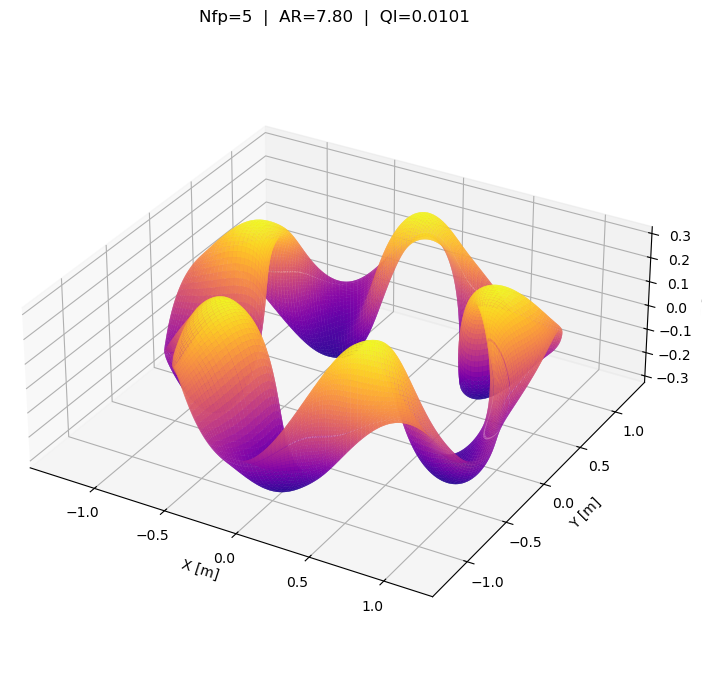

In [10]:
r_cos = np.array(row["boundary.r_cos"])
z_sin = np.array(row["boundary.z_sin"])
Nfp   = row["boundary.n_field_periods"]


# Derive mode numbers directly from array shape — don't trust n_periodicity
m_max   = r_cos.shape[0]           # 5  → m = 0, 1, 2, 3, 4
n_cols  = r_cos.shape[1]           # 9  → n = -4, -3, ..., 0, ..., 4
nmax_actual = (n_cols - 1) // 2    # 4

print("m_max:", m_max, "  nmax_actual:", nmax_actual)
print("R_00:", r_cos[0, nmax_actual])   # should now be ~0.7–1.0

# Reconstruct
N_theta, N_phi = 128, 128
theta = np.linspace(0, 2*np.pi, N_theta, endpoint=False)
phi   = np.linspace(0, 2*np.pi / Nfp, N_phi, endpoint=False)
TH, PH = np.meshgrid(theta, phi)

R = np.zeros_like(TH)
Z = np.zeros_like(TH)

for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual          # maps ni=0→n=-4, ni=4→n=0, ni=8→n=+4
        angle = m * TH - n * Nfp * PH
        R += r_cos[m, ni] * np.cos(angle)
        Z += z_sin[m, ni] * np.sin(angle)

print("R range:", R.min(), R.max())   # expect ~0.5 to 1.5
print("Z range:", Z.min(), Z.max())   # expect ~-0.3 to 0.3

# To one full torus (repeat Nfp times around phi)
phi_full  = np.linspace(0, 2*np.pi, N_phi * Nfp, endpoint=False)
TH2, PH2  = np.meshgrid(theta, phi_full)

R2 = np.zeros_like(TH2)
Z2 = np.zeros_like(TH2)
for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual
        angle = m * TH2 - n * Nfp * PH2
        R2 += r_cos[m, ni] * np.cos(angle)
        Z2 += z_sin[m, ni] * np.sin(angle)

X2 = R2 * np.cos(PH2)
Y2 = R2 * np.sin(PH2)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X2, Y2, Z2, cmap='plasma', alpha=0.9,
                rstride=2, cstride=2)
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_box_aspect([1, 1, 0.4])    # flatten Z so the torus doesn't look squashed
ax.set_title(f"Nfp={Nfp}  |  AR={row['metrics.aspect_ratio']:.2f}  |  QI={row['metrics.qi']:.4f}")
plt.tight_layout()
plt.show()

In [11]:
def make_tf_coils_circular(n_tf, R_inner, r_coil, n_points=300):
    """
    True toroidal field coils — circles in meridional planes encircling the z-axis.
    
    n_tf      : number of coils evenly spaced in toroidal angle
    R_inner   : innermost radial extent of coil [m]
    r_coil    : radius of the circular coil in the R-Z plane [m]
    n_points  : points per coil
    """
    R_centre = R_inner + r_coil   # R of circle centre in the R-Z plane

    # Poloidal angle around the coil cross-section
    alpha = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    # Coil shape in R-Z plane — a circle of radius r_coil centred at (R_centre, 0)
    R_coil_rz = R_centre + r_coil * np.cos(alpha)   # radial position of each point
    Z_coil_rz = r_coil * np.sin(alpha)              # vertical position of each point

    tf_coils = []
    for k in range(n_tf):
        phi_val = 2 * np.pi * k / n_tf   # toroidal angle of this coil

        # Convert to Cartesian — each coil lives at a fixed phi_val
        X_coil = R_coil_rz * np.cos(phi_val)
        Y_coil = R_coil_rz * np.sin(phi_val)
        Z_coil = Z_coil_rz.copy()

        tf_coils.append({
            "phi_val": phi_val,
            "R": R_coil_rz.copy(),
            "Z": Z_coil_rz.copy(),
            "X": X_coil,
            "Y": Y_coil
        })

    return tf_coils, R_centre, r_coil

n_tf = 16
R_inner_tf = 0.2
r_coil_tf  = 0.80

tf_coils, R_centre, _ = make_tf_coils_circular(
    n_tf=n_tf, R_inner=R_inner_tf, r_coil=r_coil_tf, n_points=300
)

print(f"Coil centre:  R = {R_centre:.2f} m")
print(f"Inner extent: R = {R_inner_tf:.2f} m")
print(f"Outer extent: R = {R_inner_tf + 2*r_coil_tf:.2f} m")
print(f"Z extent:     ±{r_coil_tf:.2f} m")
print(f"Plasma R range: {R.min():.2f} – {R.max():.2f} m")

Coil centre:  R = 1.00 m
Inner extent: R = 0.20 m
Outer extent: R = 1.80 m
Z extent:     ±0.80 m
Plasma R range: 0.65 – 1.29 m


In [12]:
fig = go.Figure()

# Plasma surface
fig.add_trace(go.Surface(x=X2, y=Y2, z=Z2, opacity=0.2,
                          colorscale='Greys', showscale=False, name='Plasma'))

colors_tf = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow',
             'pink', 'brown', 'lime', 'teal', 'coral', 'gold', 'indigo', 'turquoise']

for i, coil in enumerate(tf_coils):
    fig.add_trace(go.Scatter3d(
        x=coil["X"], y=coil["Y"], z=coil["Z"],
        mode='lines',
        line=dict(color=colors_tf[i], width=3),
        name=f'TF {i+1} (φ={coil["phi_val"]:.2f})'
    ))

fig.update_layout(
    title=f"16 circular TF coils  |  R_centre={R_centre:.2f}m  r_coil={r_coil:.2f}m",
    scene=dict(aspectmode='data',
               xaxis_title='X [m]', yaxis_title='Y [m]', zaxis_title='Z [m]'),
    width=900, height=700
)
fig.show()

In [13]:
print(f"r_coil = {r_coil}")
print(f"R_centre = {R_centre}") 
print(f"R_coil_rz min = {(R_centre + r_coil * np.cos(np.linspace(0, 2*np.pi, 300))).min():.3f}")
print(f"R_coil_rz max = {(R_centre + r_coil * np.cos(np.linspace(0, 2*np.pi, 300))).max():.3f}")

r_coil = 0.65
R_centre = 1.0
R_coil_rz min = 0.350
R_coil_rz max = 1.650


In [14]:
# Precompute all segments stacked for fast evaluation
R0 = r_cos[0, nmax_actual] # Approximate plasma centre
mu0 = 4 * np.pi * 1e-7 # Permeability of free space [T m / A]

I_coil = 1.0 # Current in coils [A]

# Plasma current strength: I_plasma = 0.0 corresponds to the vacuum magnetic field
# Will be varied in Part 2 to study confinement
I_plasma = 0.0 

# Split the coils into small segments 
def coil_segments(coil):
    """
        segment_mid: midpoint of each straight-line current segment 
        dl: segment vectors pointing along the current direction
    """
    points = np.column_stack((coil["X"], coil["Y"], coil["Z"]))
    points_loop = np.vstack([points, points[0]])
    dl = points_loop[1:] - points_loop[:-1] # segments on coil
    segments_mid = 0.5 * (points_loop[1:] + points_loop[:-1])

    return segments_mid, dl

tf_segments = []
for coil in tf_coils:
    seg_mid, dl = coil_segments(coil)
    tf_segments.append({"segments_mid": seg_mid, "dl": dl})

all_tf_mids = np.vstack([c["segments_mid"] for c in tf_segments])
all_tf_dl   = np.vstack([c["dl"]           for c in tf_segments])

def B_tf(point, I_coil=1.0):
    r_vec = point - all_tf_mids
    r_mag = np.maximum(np.linalg.norm(r_vec, axis=1), 1e-8)
    dB    = (mu0 * I_coil / (4*np.pi)) * np.cross(all_tf_dl, r_vec) / r_mag[:,None]**3
    return dB.sum(axis=0)

# On the midplane Z=0, B_phi should scale as 1/R
# B_phi * R should be constant — that's your validation
print(f"{'R':>6}  {'B_phi':>12}  {'B_phi*R':>12}  {'B_R':>10}  {'B_z':>10}")
print("─" * 56)

expected_const = None
for test_R in [0.5, 0.7, 0.8, 0.9, R0, 1.1, 1.2, 1.4]:
    pt  = np.array([test_R, 0.0, 0.0])
    B   = B_tf(pt)
    # At y=0: phi-hat = (0,1,0), R-hat = (1,0,0)
    B_phi_val = B[1]
    B_R_val   = B[0]
    B_z_val   = B[2]
    product   = B_phi_val * test_R
    if expected_const is None:
        expected_const = product
    rel_err = abs(product - expected_const) / abs(expected_const)
    print(f"{test_R:>6.2f}  {B_phi_val:>12.4e}  {product:>12.4e}"
          f"  {B_R_val:>10.4e}  {B_z_val:>10.4e}  rel_err={rel_err:.4f}")

     R         B_phi       B_phi*R         B_R         B_z
────────────────────────────────────────────────────────
  0.50   -6.4002e-06   -3.2001e-06  -8.0133e-23  -6.3714e-23  rel_err=0.0000
  0.70   -4.5716e-06   -3.2001e-06  -2.6046e-22  -7.4285e-24  rel_err=0.0000
  0.80   -4.0002e-06   -3.2001e-06  3.3335e-22  6.0849e-23  rel_err=0.0000
  0.90   -3.5558e-06   -3.2002e-06  2.4195e-22  -3.5529e-23  rel_err=0.0000
  1.00   -3.2023e-06   -3.2007e-06  1.0939e-22  4.0330e-23  rel_err=0.0002
  1.10   -2.9113e-06   -3.2024e-06  -1.7598e-22  6.1412e-23  rel_err=0.0007
  1.20   -2.6737e-06   -3.2084e-06  4.8514e-22  -7.5876e-23  rel_err=0.0026
  1.40   -2.3450e-06   -3.2829e-06  4.9755e-22  -3.3023e-24  rel_err=0.0259



**`B_phi * R` is essentially constant** from R=0.5 to R=1.2 — rel_err stays below 0.3% across the entire plasma region (0.65–1.29m). It only starts drifting at R=1.4, which is outside the plasma boundary anyway and close to the coil wire itself.

**`B_R` and `B_z` are negligible** — order 1e-22, pure numerical noise. The field is purely toroidal on the midplane as expected.

**`B_phi` is negative** — this just means current is flowing clockwise when viewed from above. Physically fine, just means the field points in the $-\hat{\phi}$ direction. You can flip it by reversing current direction (`I_coil = -1.0`) if you want positive convention.

TF coils produce the correct $B_\phi \propto 1/R$ toroidal field inside the plasma volume.

In [15]:
# Design the helical coils
def make_helical_coils(R0, a, n_wind, n_coils=2, n_points=1000):
    coils_h = []
    for k in range(n_coils):
        theta_offset = 2 * np.pi * k / n_coils   # poloidal offset between coils

        # Poloidal angle 
        theta = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

        # Toroidal angle 
        phi_h = n_wind * theta + theta_offset

        R_coil = R0 + a * np.cos(theta) # distance from z-axis
        Z_coil = a * np.sin(theta)

        coils_h.append({
            "X": R_coil * np.cos(phi_h),
            "Y": R_coil * np.sin(phi_h),
            "Z": Z_coil,
        })
    return coils_h

a_coil_h = 0.45 # Coil 0.45m outside the plasma
n_wind    = 2    

helical_coils = make_helical_coils(R0, a=a_coil_h, n_wind=n_wind, n_coils=2)

In [16]:
fig = go.Figure()

# Plasma surface
fig.add_trace(go.Surface(x=X2, y=Y2, z=Z2, opacity=0.15,
                          colorscale='Greys', showscale=False, name='Plasma'))

# TF coils
for i, coil in enumerate(tf_coils):
    fig.add_trace(go.Scatter3d(
        x=coil["X"], y=coil["Y"], z=coil["Z"],
        mode='lines',
        line=dict(color='steelblue', width=2),
        name=f'TF {i+1}',
        showlegend=(i == 0)
    ))

# Helical coils
hel_colors = ['red', 'orange']
for i, coil in enumerate(helical_coils):
    fig.add_trace(go.Scatter3d(
        x=coil["X"], y=coil["Y"], z=coil["Z"],
        mode='lines',
        line=dict(color=hel_colors[i], width=4),
        name=f'Helical coil {i+1}'
    ))

fig.update_layout(
    title=f"TF coils + 2 helical coils (a={a_coil_h}m, n_wind={n_wind})",
    scene=dict(aspectmode='data',
               xaxis_title='X [m]', yaxis_title='Y [m]', zaxis_title='Z [m]'),
    width=900, height=700
)
fig.show()

In [17]:
I_tf  = -1.0
I_hel = -0.3

# Precompute helical segments
hel_segments = []
for coil in helical_coils:
    seg_mid, dl = coil_segments(coil)
    hel_segments.append({"segments_mid": seg_mid, "dl": dl})

all_hel_mids = np.vstack([c["segments_mid"] for c in hel_segments])
all_hel_dl   = np.vstack([c["dl"]           for c in hel_segments])

def B_helical(point, I_hel):
    r_vec = point - all_hel_mids
    r_mag = np.maximum(np.linalg.norm(r_vec, axis=1), 1e-8)
    dB    = (mu0 * I_hel / (4*np.pi)) * np.cross(all_hel_dl, r_vec) / r_mag[:,None]**3
    return dB.sum(axis=0)

def B_total_coils(point, I_tf, I_hel):
    return B_tf(point, I_tf) + B_helical(point, I_hel)

# Check field decomposition — B_tor should dominate, B_pol should be ~iota * B_tor
print(f"{'R':>6}  {'B_tor':>12}  {'B_pol':>12}  {'ratio B_pol/B_tor':>18}")
print("─" * 54)
for test_R in [0.7, 0.8, 0.9, R0, 1.1, 1.2]:
    pt    = np.array([test_R, 0.0, 0.0])
    B     = B_total_coils(pt, I_tf, I_hel)
    e_phi = np.array([0.0, 1.0, 0.0])   # phi-hat at y=0
    B_tor = np.dot(B, e_phi)
    B_pol = np.linalg.norm(B - B_tor * e_phi)
    print(f"{test_R:>6.2f}  {B_tor:>12.4e}  {B_pol:>12.4e}  {B_pol/abs(B_tor):>18.4f}")

     R         B_tor         B_pol   ratio B_pol/B_tor
──────────────────────────────────────────────────────
  0.70    4.7743e-06    1.7916e-07              0.0375
  0.80    4.1537e-06    2.8061e-07              0.0676
  0.90    3.6892e-06    2.9418e-07              0.0797
  1.00    3.3224e-06    2.8136e-07              0.0847
  1.10    3.0208e-06    2.7605e-07              0.0914
  1.20    2.7786e-06    3.1283e-07              0.1126


In [18]:
def trace_one_coils(seed, seed_idx, N_steps, ds,
                    tf_mids, tf_dl, hel_mids, hel_dl,
                    I_tf, I_hel, mu0):
    """Fully self-contained — no globals, safe for loky."""

    def B_total(point):
        # TF contribution
        r_vec  = point - tf_mids
        r_mag  = np.maximum(np.linalg.norm(r_vec, axis=1), 1e-8)
        dB_tf  = (mu0 * I_tf  / (4*np.pi)) * np.cross(tf_dl,  r_vec) / r_mag[:,None]**3

        # Helical contribution
        r_vec2 = point - hel_mids
        r_mag2 = np.maximum(np.linalg.norm(r_vec2, axis=1), 1e-8)
        dB_hel = (mu0 * I_hel / (4*np.pi)) * np.cross(hel_dl, r_vec2) / r_mag2[:,None]**3

        return dB_tf.sum(axis=0) + dB_hel.sum(axis=0)

    def rk4_step(r, ds):
        def rhs(r):
            B = B_total(r)
            Bmag = np.linalg.norm(B)
            return B / Bmag if Bmag > 1e-12 else np.zeros(3)
        k1 = rhs(r)
        k2 = rhs(r + 0.5 * ds * k1)
        k3 = rhs(r + 0.5 * ds * k2)
        k4 = rhs(r + ds * k3)
        return r + (ds / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    r    = seed.copy()
    prev = r.copy()
    crossings = []

    for _ in range(N_steps):
        r = rk4_step(r, ds)
        y0, y1 = prev[1], r[1]
        if y0 < 0 and y1 >= 0 and r[0] > 0:
            frac = -y0 / (y1 - y0)
            pt   = prev + frac * (r - prev)
            R_cross = np.sqrt(pt[0]**2 + pt[1]**2)
            crossings.append((R_cross, pt[2], seed_idx))
        prev = r.copy()

    return crossings

seeds_coils = [
    np.array([R0 - 0.15, 0.0, 0.0]),
    np.array([R0 - 0.07, 0.0, 0.0]),
    np.array([R0,        0.0, 0.0]),
    np.array([R0 + 0.07, 0.0, 0.0]),
    np.array([R0 + 0.15, 0.0, 0.0]),
]

N_steps_coils = 200000
ds_coils      = 0.01
n_jobs        = min(os.cpu_count(), len(seeds_coils))


# Pass all arrays explicitly
results = Parallel(n_jobs=n_jobs, backend='loky')(
    delayed(trace_one_coils)(
        seed, idx, N_steps_coils, ds_coils,
        all_tf_mids, all_tf_dl,
        all_hel_mids, all_hel_dl,
        I_tf, I_hel, mu0
    )
    for idx, seed in enumerate(seeds_coils)
)

Total crossings: 1379
  Seed 1 (R=0.85): 291 crossings
  Seed 2 (R=0.93): 278 crossings
  Seed 3 (R=1.00): 280 crossings
  Seed 4 (R=1.07): 266 crossings
  Seed 5 (R=1.15): 264 crossings


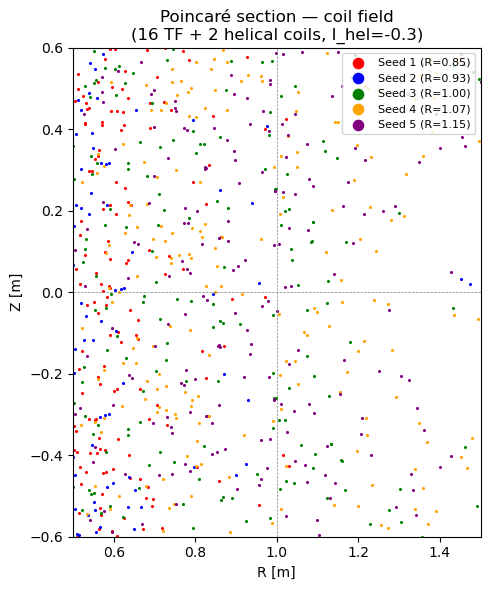

In [21]:
# Flatten crossings
flat = [c for sublist in results for c in sublist]
crossings_coils = np.array(flat) if flat else np.empty((0, 3))

print(f"Total crossings: {len(crossings_coils)}")
for i in range(len(seeds_coils)):
    n = np.sum(crossings_coils[:, 2] == i) if len(crossings_coils) > 0 else 0
    print(f"  Seed {i+1} (R={seeds_coils[i][0]:.2f}): {n} crossings")

# Plot
colors_poinc = ['red', 'blue', 'green', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(7, 6))

if len(crossings_coils) > 0:
    for seed_idx, color in enumerate(colors_poinc):
        mask = crossings_coils[:, 2] == seed_idx
        pts  = crossings_coils[mask]
        if len(pts) > 0:
            ax.scatter(pts[:, 0], pts[:, 1], s=1.5, color=color,
                       label=f'Seed {seed_idx+1} (R={seeds_coils[seed_idx][0]:.2f})')

ax.set_xlim(0.5, 1.5)
ax.set_ylim(-0.6, 0.6)
ax.set_aspect('equal')
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.axhline(0,  color='gray', lw=0.5, ls='--')
ax.axvline(R0, color='gray', lw=0.5, ls='--')
ax.set_title(f'Poincaré section — coil field\n'
             f'(16 TF + 2 helical coils, I_hel={I_hel})')
ax.legend(markerscale=6, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()